In [1]:
import os
os.environ["WORLD_SIZE"] = "1"
os.environ["RANK"] = "0"
os.environ["LOCAL_RANK"] = "0"
os.environ["MASTER_ADDR"] = "localhost"
os.environ["MASTER_PORT"] = "12355"

# Surface Benchmarking of External Aero Flows

In this notebook, we walk through the steps required to generate a sample model inference on a simulation mesh and to compare the model's predictions with ground-truth data across several metrics relevant to external aerodynamics. This notebook uses the surface results from the [DrivAerML dataset](https://caemldatasets.org/drivaerml/). Specifically, we use sample ID `202` to compute all metrics and comparisons.

## Prerequisites

For running this notebook, ensure that you have installed the library using `[gpu]` optional dependency group. This can be done using:

```bash
pip install .[gpu] --extra-index-url=https://pypi.nvidia.com
```

## Compute model inference on the benchmark simulation

The benchmark results are saved in `.vtp` (surface) and `.vtu` (volume) formats. For this notebook, let's start by loading the `.vtp` file and inspecting the available fields. We will use the [`pyvista`](https://pyvista.org/) library for this purpose.

### Download the benchmark solution

Let's download the solution from the [DrivAerML dataset](https://huggingface.co/datasets/neashton/drivaerml).

In [2]:
import os

filenames = [
    "drivaer_202.stl",
    "boundary_202.vtp",
]
urls = [
    "https://huggingface.co/datasets/neashton/drivaerml/resolve/main/run_202/drivaer_202.stl",
    "https://huggingface.co/datasets/neashton/drivaerml/resolve/main/run_202/boundary_202.vtp",
]

for filename, url in zip(filenames, urls):
    if not os.path.exists(filename):
        !wget --quiet "{url}" -O "{filename}"
    else:
        print(f"{filename} already exists. Skipping download.")

drivaer_202.stl already exists. Skipping download.
boundary_202.vtp already exists. Skipping download.


In [3]:
import pyvista as pv

mesh = pv.read("./boundary_202.vtp")
mesh

PolyData (0x78193f7ddf00)
  N Cells:    8883343
  N Points:   8902069
  N Strips:   0
  X Bounds:   -9.240e-01, 3.886e+00
  Y Bounds:   -1.061e+00, 1.061e+00
  Z Bounds:   -3.176e-01, 1.074e+00
  N Arrays:   5

We observe that the mesh contains `8,902,069` points and `8,883,343` cells. The pressure and wall shear stress variables are stored as `pMeanTrim` and `wallShearStressMeanTrim`. We'll denote the model's predictions as `pMeanTrimPred` and `wallShearStressMeanTrimPred`. We compute the inference using the GeoTransolver model wrapper with a pretrained checkpoint. You can adapt the code to your specific model inputs/outputs.

---



In [4]:
import time
from physicsnemo.cfd.evaluation.models.wrappers.geotransolver.wrapper import GeoTransolverWrapper
from physicsnemo.cfd.evaluation.assets import resolve_model_assets
from physicsnemo.cfd.evaluation.config import ModelConfig
from physicsnemo.cfd.evaluation.datasets.schema import CanonicalCase

# Resolve GeoTransolver checkpoint + stats from Hugging Face via ``builtin_packages``.
# Set ``checkpoint=...`` / ``stats_path=...`` on ``ModelConfig`` to override with local paths.
cfg = ModelConfig(name="geotransolver_surface", checkpoint="", stats_path="")
ck_path, st_path, _aid, load_kw = resolve_model_assets(cfg, GeoTransolverWrapper)

wrapper = GeoTransolverWrapper()
wrapper.load(
    checkpoint_path=ck_path,
    stats_path=st_path,
    device="cuda:0",
    inference_domain="surface",
    batch_resolution=60000,
    geometry_sampling=300000,
    **load_kw,
)

case = CanonicalCase(
    case_id="run_202",
    mesh_path="./boundary_202.vtp",
    mesh_type="cell",
    inference_domain="surface",
)

start_time = time.time()
model_input = wrapper.prepare_inputs(case)
raw_output = wrapper.predict(model_input)
predictions = wrapper.decode_outputs(raw_output, case)

mesh.cell_data["pMeanTrimPred"] = predictions["pressure"]
mesh.cell_data["wallShearStressMeanTrimPred"] = predictions["shear_stress"]
print(f"Inference took {time.time() - start_time:.3f} sec")

mesh


/localhome/local-ktangsali/development_workspace/physicsnemo-cfd-api-docs/physicsnemo-cfd/physicsnemo/cfd/evaluation/models/wrappers/geotransolver/wrapper.py:66: ExperimentalFeatureWarning: You are importing from 'physicsnemo.experimental'. The APIs in this namespace are experimental, under active development, and may change without notice. Expect possible back-compatibility breaking changes and only partial test coverage.
  from physicsnemo.experimental.models.geotransolver import GeoTransolver


config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

geotransolver_drivaerml_surface_checkpoi(…):   0%|          | 0.00/118M [00:00<?, ?B/s]

global_stats.json: 0.00B [00:00, ?B/s]

[inference:geotransolver] Loading surface normalization from /localhome/local-ktangsali/.cache/physicsnemo-cfd/models/packages/geotransolver_surface/models--nvidia--geotransolver_drivaerml/snapshots/ddda24db315f6fca8d67c76f3da511ea4d9da86e/geotransolver_drivaerml_surface_checkpoint/global_stats.json


...

[inference:geotransolver] Reading case inputs (case run_202): mesh ./boundary_202.vtp, run dir .


[inference:geotransolver] Running forward pass (predicting fields)…


[inference:geotransolver] Decoding outputs (pressure + WSS to numpy)…


Inference took 199.534 sec


PolyData (0x78193f7ddf00)
  N Cells:    8883343
  N Points:   8902069
  N Strips:   0
  X Bounds:   -9.240e-01, 3.886e+00
  Y Bounds:   -1.061e+00, 1.061e+00
  Z Bounds:   -3.176e-01, 1.074e+00
  N Arrays:   7

Now that we have both the predicted and true fields on the same points (cell centers to be precise), we can start with comparing these two solutions.

## L2 Errors

Let's compare the L2 errors for the pressure and the wall shear stress fields. We will use the `compute_l2_errors` function from the library. 

In [5]:
from physicsnemo.cfd.postprocessing_tools.metrics.l2_errors import compute_l2_errors

l2_errors = compute_l2_errors(
    mesh,
    true_fields=["pMeanTrim", "wallShearStressMeanTrim"],
    pred_fields=["pMeanTrimPred", "wallShearStressMeanTrimPred"],
    dtype="cell",
)
l2_errors

{'pMeanTrim_l2_error': 0.051371125091876906,
 'wallShearStressMeanTrim_x_l2_error': 0.08172523641549526,
 'wallShearStressMeanTrim_y_l2_error': 0.10229493980696161,
 'wallShearStressMeanTrim_z_l2_error': 0.11043629712396553}

This provides a numerical comparison of the model's overall performance.

Meshes are typically refined with smaller triangles in areas of high geometric detail. We can compute area-weighted L2 errors to see how the error relates to cell size using `compute_area_weighted_l2_errors`. Note: this metric only works for `cell` dtype.

In [6]:
from physicsnemo.cfd.postprocessing_tools.metrics.l2_errors import compute_area_weighted_l2_errors

area_weighted_l2_errors = compute_area_weighted_l2_errors(
    mesh,
    true_fields=["pMeanTrim", "wallShearStressMeanTrim"],
    pred_fields=["pMeanTrimPred", "wallShearStressMeanTrimPred"],
    dtype="cell",
)
area_weighted_l2_errors

{'pMeanTrim_area_wt_l2_error': 0.06262383543084056,
 'wallShearStressMeanTrim_x_area_wt_l2_error': 0.06660008475751546,
 'wallShearStressMeanTrim_y_area_wt_l2_error': 0.13517764268770657,
 'wallShearStressMeanTrim_z_area_wt_l2_error': 0.11530573075664872}

## Computing drag metrics

Drag force is an important consideration for the efficiency and performance of the vehicle. We can use the `compute_drag_and_lift` function to compute the drag and lift coefficient / forces

In [7]:
from physicsnemo.cfd.postprocessing_tools.metrics.aero_forces import compute_drag_and_lift

forces_true = compute_drag_and_lift(
    mesh,
    pressure_field="pMeanTrim",
    wss_field="wallShearStressMeanTrim",
    coeff=1.0,  # Set it to 1.0 to get raw forces. can be replaced 2 / (rho * u * u * ref_area) for coefficients
    drag_direction=[1, 0, 0],
    lift_direction=[0, 0, 1],
    dtype="cell",
)  # returns F_drag, F_drag_pressure, F_drag_skin_friction, F_lift, F_lift_pressure, F_lift_skin_friction

forces_pred = compute_drag_and_lift(
    mesh,
    pressure_field="pMeanTrimPred",
    wss_field="wallShearStressMeanTrimPred",
    coeff=1.0,  # Set it to 1.0 to get raw forces. can be replaced 2 / (rho * u * u * ref_area) for coefficients
    drag_direction=[1, 0, 0],
    lift_direction=[0, 0, 1],
    dtype="cell",
)  # returns F_drag, F_drag_pressure, F_drag_skin_friction, F_lift, F_lift_pressure, F_lift_skin_friction

labels = ["Drag Force (D)", "D_p", "D_f", "Lift Force (L)", "L_p", "L_f"]
for label, f_true, f_pred in zip(labels, forces_true, forces_pred):
    print(
        f"{label}: True: {f_true}, Pred: {f_pred}, Error (%): {abs(f_true - f_pred) * 100 / f_true}"
    )

Drag Force (D): True: 482.34442543026296, Pred: 480.9263272540978, Error (%): 0.29400115382284203
D_p: True: 435.0610781379877, Pred: 433.5139702801921, Error (%): 0.35560704819126593
D_f: True: 47.28334729227525, Pred: 47.412356973905716, Error (%): 0.2728438002348038
Lift Force (L): True: 37.28053920122968, Pred: 38.23586740873885, Error (%): 2.562538600508379
L_p: True: 34.24916887927543, Pred: 35.08140038060594, Error (%): 2.4299319620398276
L_f: True: 3.0313703219542463, Pred: 3.1544670281329075, Error (%): 4.0607610784849255


When computing drag and lift across many cases, you can use visualization utilities such as `physicsnemo.cfd.postprocessing_tools.visualization.utils.plot_design_scatter` and `physicsnemo.cfd.postprocessing_tools.visualization.utils.plot_design_trend` to compute metrics (e.g., R2 scores), compare design trends, and measure the ability of models to capture directional changes. The workflow scripts ([../generate_surface_benchmarks.py](../generate_surface_benchmarks.py) and [../generate_volume_benchmarks.py](../generate_volume_benchmarks.py)) use these functions to create plots like the examples below:

![Sample R2 score plot](img/design_scatter_plot.png)

![Sample design trend plot](img/design_trend_plot.png)


## Plotting fields

So far, we have examined numerical metrics, which are important for analysis. However, visualizing the flow fields is often critical for understanding flow behavior (e.g., separation regions and stagnation points).

2026-05-09 06:24:17.920 ( 247.588s) [    7819A57C4080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


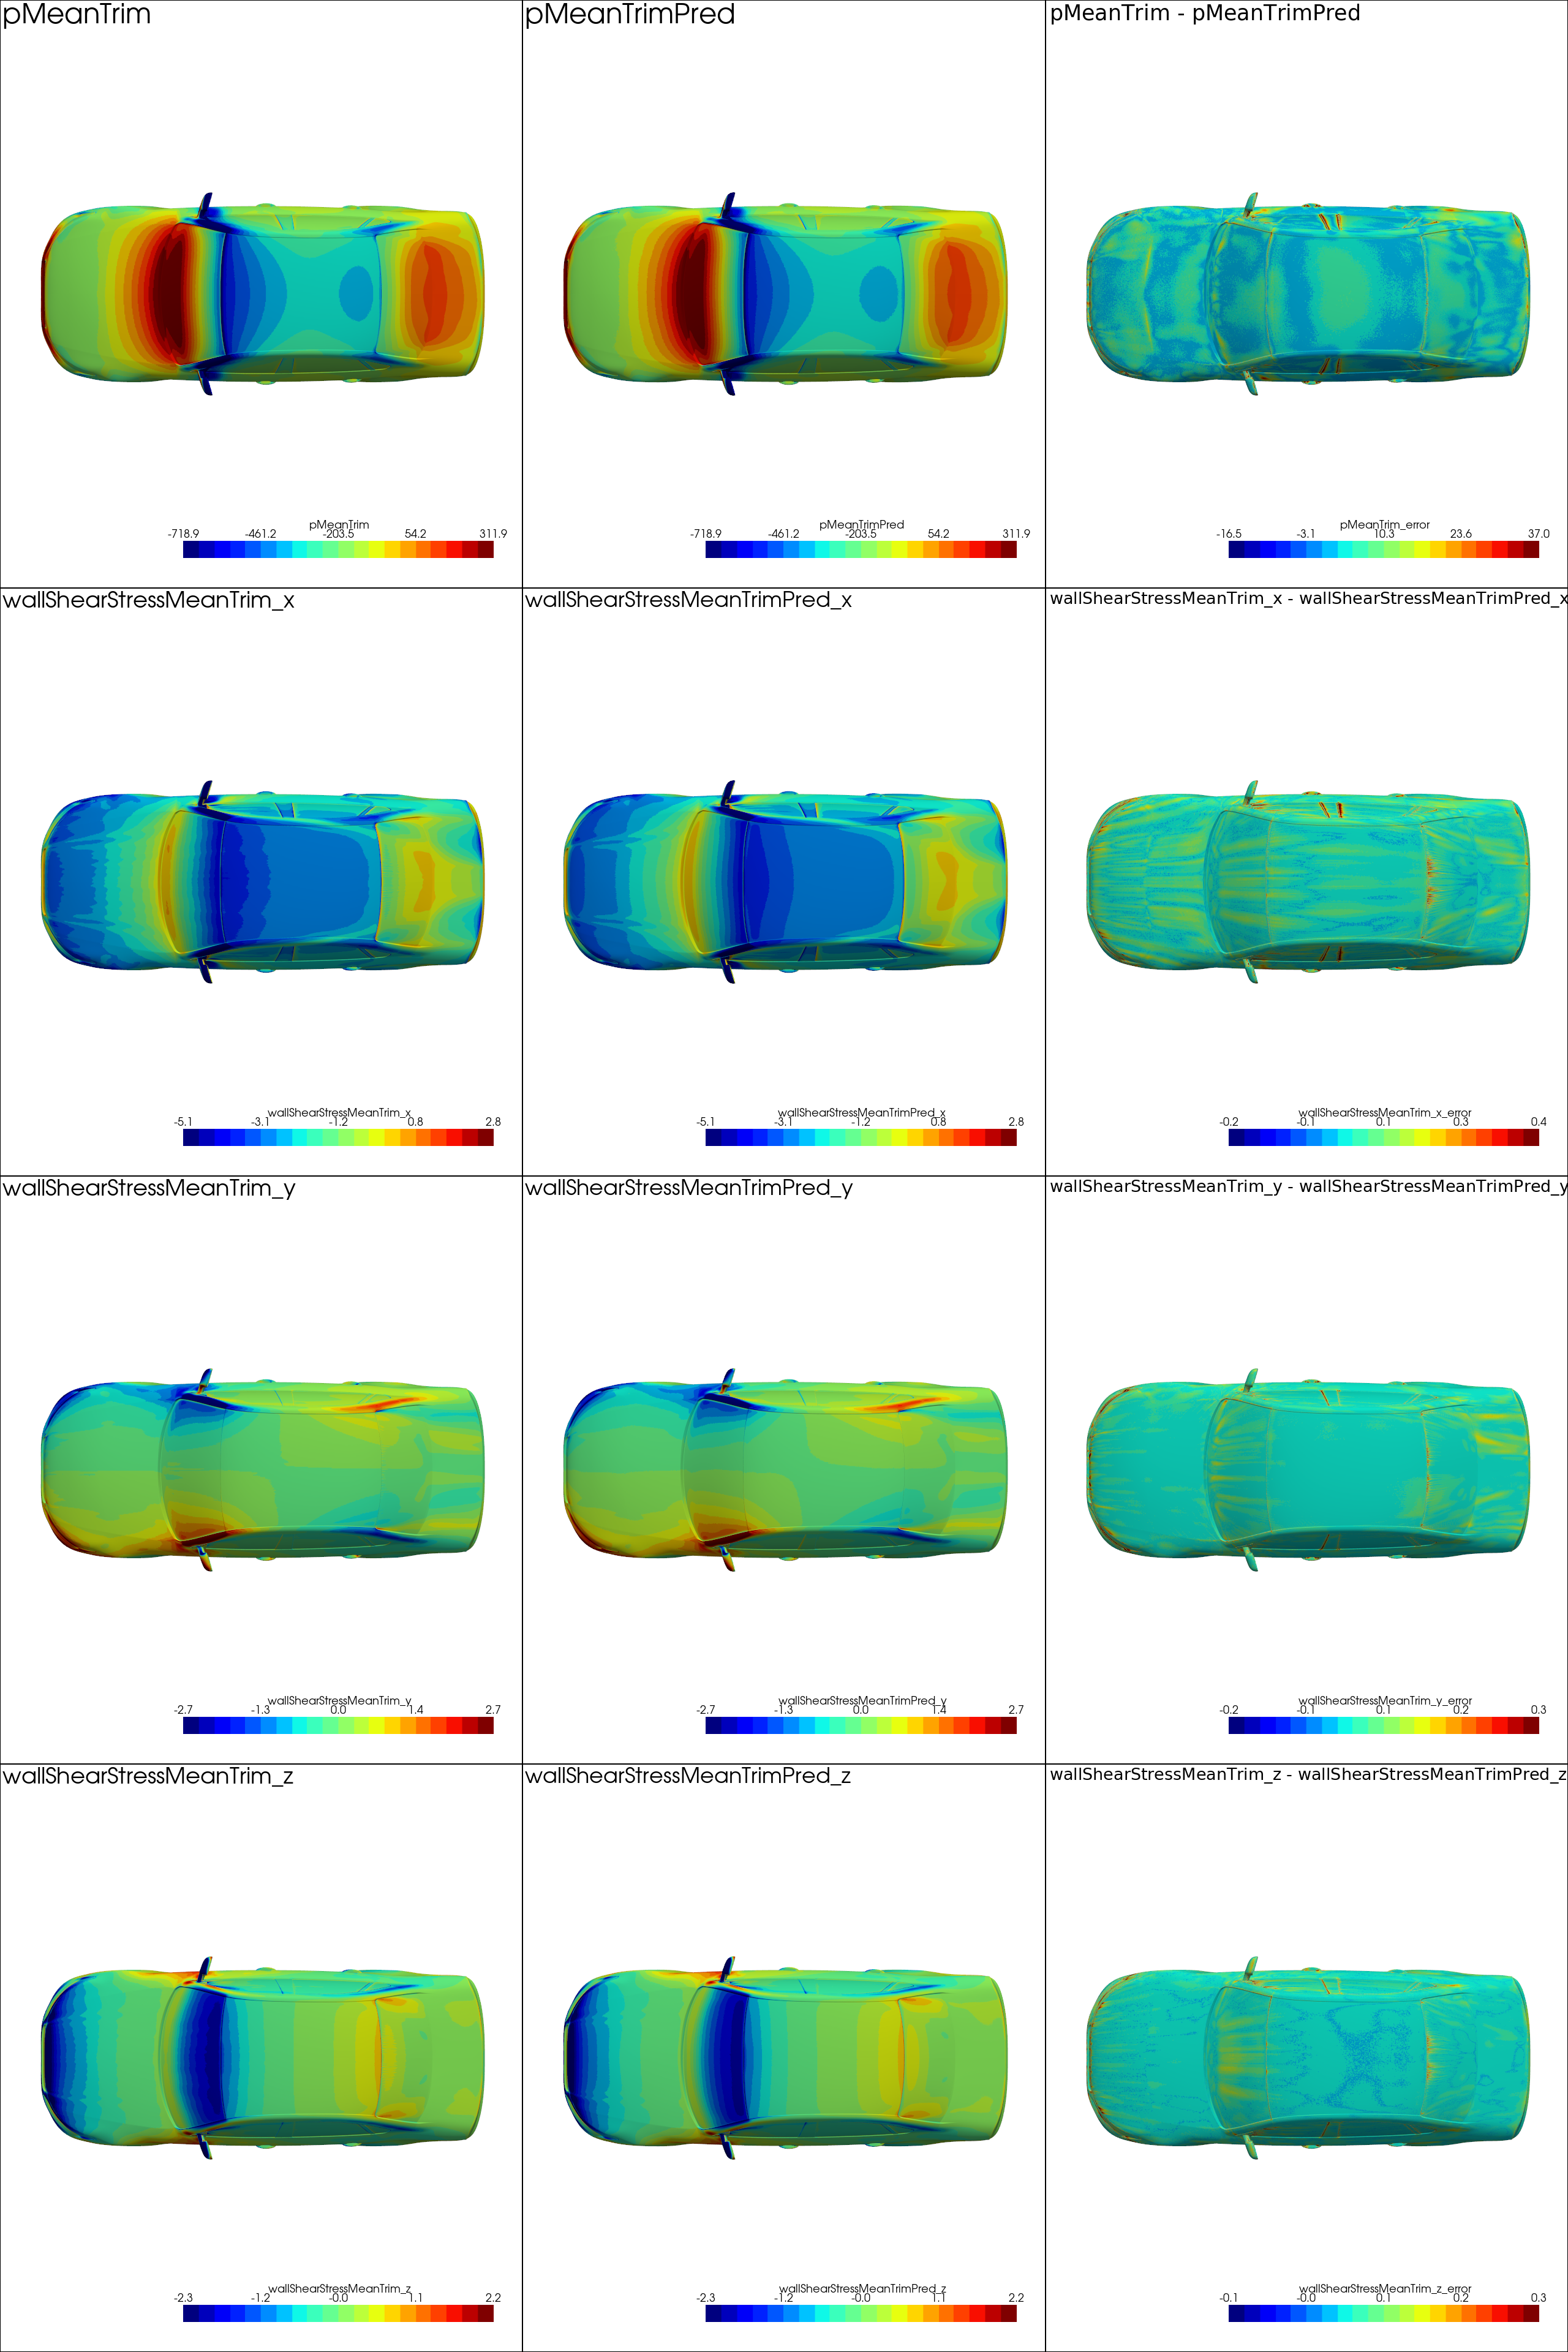

In [8]:
from physicsnemo.cfd.postprocessing_tools.visualization.utils import plot_field_comparisons

_xvfb = getattr(pv, "start_xvfb", None)
if _xvfb is not None:
    _xvfb()
else:
    pv.OFF_SCREEN = True

plotter = plot_field_comparisons(
    mesh,
    true_fields=["pMeanTrim", "wallShearStressMeanTrim"],
    pred_fields=["pMeanTrimPred", "wallShearStressMeanTrimPred"],
    view="xy",
    plot_vector_components=True,
    cmap="jet",
    lut=20,
)
plotter.screenshot("./sample_202_surface_comparison.png")

# Display the image
from IPython.display import Image

Image(filename="./sample_202_surface_comparison.png")

The visualization reveals that the AI prediction captures the larger structures in the flow field for most variables, except the x-component of wall shear stress, where it struggles with the flow structures on the hood and roof. For other variables, larger errors are observed near the mirrors and sharp edges.

Such visualizations do not show how predictions look across the entire validation dataset. For that, one can project errors from different samples onto fixed planes and build aggregate visualizations. The [`../generate_surface_benchmarks.py`](../generate_surface_benchmarks.py) script provides this capability.

Below we show the error distribution across the entire DrivAerML validation set.

![Aggregate Errors](img/hexbin_sample.png)

Overall, errors are typically higher near the intersections of the front windshield with the roof and the rear windshield with the roof. Errors are also higher near the front of the vehicle.

Such analysis is especially useful when geometric differences between samples are modest (e.g., DrivAerML), where such projections enable meaningful aggregate visualizations.

We can also create line plots for more detailed visualization and comparison. Here, we plot the pressure along the centerline of the car.

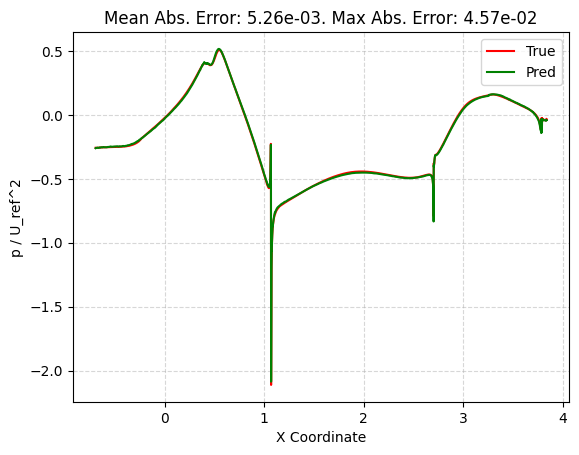

In [9]:
from physicsnemo.cfd.postprocessing_tools.visualization.utils import plot_line

# create a slice along xz plane
centerline = mesh.slice(origin=(0, 0, 0), normal=(0, 1, 0))
centerline = centerline.clip(
    origin=(0, 0, 0.4), normal=(0, 0, 1), invert=False
)  # Select only the top half
centerline = centerline.cell_data_to_point_data(pass_cell_data=True)

fig = plot_line(
    centerline,
    plot_coord="x",
    field_true="pMeanTrim",
    field_pred="pMeanTrimPred",
    normalize_factor=(38.89**2) / 2,
    flip=False,
    xlabel="X Coordinate",
    ylabel="p / U_ref^2",
    true_line_kwargs={"color": "red", "label": "True"},
    pred_line_kwargs={"color": "green", "label": "Pred"},
    figsize=(6, 4),
)

Aside from the sharp peaks, the centerline pressure matches the ground truth well.

Streamlines provide another way to visualize the flow fields and gain deeper insight into flow behavior. For surface results, we can create streamlines of wall shear stress. Below, we create streamlines using `physicsnemo.cfd.postprocessing_tools.metrics.streamlines.compute_streamlines` and overlay them on the geometry STL for clarity.

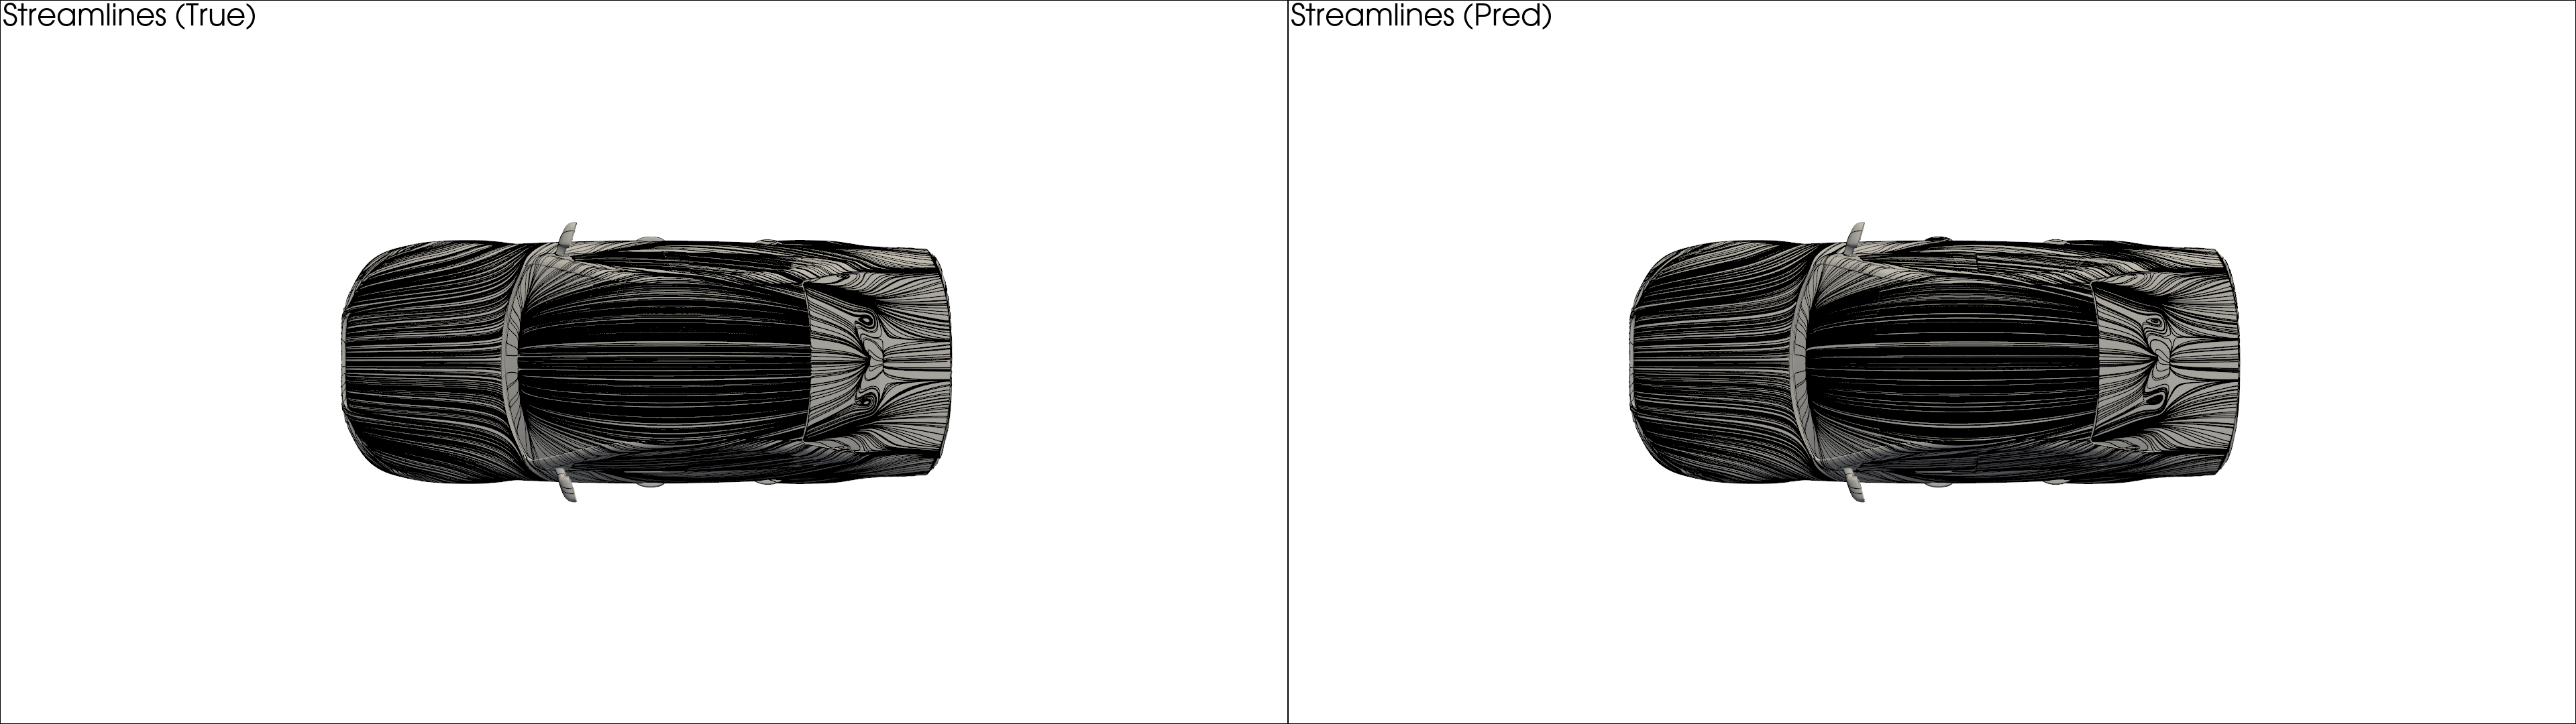

In [10]:
import numpy as np
from physicsnemo.cfd.postprocessing_tools.metrics.streamlines import compute_streamlines
from physicsnemo.cfd.postprocessing_tools.visualization.utils import plot_streamlines

true_streamlines = compute_streamlines(mesh, field="wallShearStressMeanTrim")
pred_streamlines = compute_streamlines(mesh, field="wallShearStressMeanTrimPred")

stl_mesh = pv.read("./drivaer_202.stl")
# Shrink the STL slightly
center = np.array(stl_mesh.center)
scale_factor = 0.999
stl_mesh = stl_mesh.translate(-center).scale(scale_factor).translate(center)

plotter = plot_streamlines(true_streamlines, pred_streamlines, stl_mesh, view="xy")
plotter.screenshot("./sample_202_streamlines.png")

# Display the image
from IPython.display import Image

Image(filename="./sample_202_streamlines.png")

That completes the surface benchmarking notebook. For volume benchmarking, see [`volume_benchmarking.ipynb`](./volume_benchmarking.ipynb). To run these metrics across multiple geometries or cases, refer to [`../generate_surface_benchmarks.py`](../generate_surface_benchmarks.py).